<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/VQE_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
font-family:'Times New Roman', Times, serif;
padding:24px;
border-radius:14px;
background: linear-gradient(135deg,#f5f7ff,#e8f0ff);
border:2px solid #cfd9ff;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
">

<p style="
font-size:40px;
text-align:center;
font-weight:bold;
color:#b30000;
margin-bottom:6px;
letter-spacing:0.5px;">
⚛️ Variational Quantum Eigensolver (VQE) Tutorial ⚛️
</p>

<p style="
font-size:22px;
text-align:center;
color:#333;
margin-top:4px;">
Hands-on Guide to <b>VQE Algorithm</b> using the <b>Qiskit SDK (v2.0+)</b>
</p>

<hr style="border:1px solid #c9d6ff; margin:16px 0;">

<p style="
font-size:19px;
color:#0a3d91;
text-align:left;">
📘 <b>Course:</b> Quantum Mechanics and Quantum Computation (CD61001)
</p>
<!--
<p style="
font-size:18px;
color:#444;
text-align:left;">
👨‍🏫 <b>Instructor:</b> Sudipta Majumder
</p> -->

<p style="
font-size:17px;
color:#444;
text-align:right;
margin-top:10px;">
🚀 Hybrid Quantum-Classical Algorithm for Ground State Problems
</p>

</div>

<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
<a id="install"></a>
<h3 style="font-weight:bold; color:red;">Install Qiskit</h3>

First, check that the version of Python you are using in your environment is python>=3.10, to make sure that it is compatible with the latest Qiskit version we will use:

In [1]:
from platform import python_version

print(python_version())

3.12.12


<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
If that is not the case, you can upgrade it using your preferred tool. If you are unsure how to do it, some recommended options are:

- MacOS: [Homebrew](https://brew.sh/)
- Linux: `sudo apt-get update `

A detailed guide on how to upgrade Python depending on your OS is detailed here: [How to update Python](https://4geeks.com/how-to/how-to-update-python-version)

<div style="
background:linear-gradient(90deg,#0f2027,#203a43,#2c5364);
padding:14px;
border-radius:10px;
margin-top:10px;
">

<h1 style="color:white;margin:0;font-family:Times New Roman;">
📖 Chapter 1 | Theoretical Overview
</h1>

</div>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">

<p style="font-size:17px;">
The <strong style="color:blue">Variational Quantum Eigensolver (VQE)</strong> is a hybrid quantum–classical algorithm used to estimate the <b>lowest eigenvalue</b> of a Hamiltonian.
In many practical problems, this corresponds to finding the <b>ground state energy</b> of a quantum system.
</p>

<p style="font-size:17px;">
VQE is one of the most important algorithms for the <b>NISQ (Noisy Intermediate-Scale Quantum)</b> era because it uses <b>relatively shallow quantum circuits</b>. This makes it more practical than algorithms such as <strong style="color:blue">Quantum Phase Estimation (QPE)</strong>, which require long coherent circuits that are difficult to run on current noisy hardware.
</p>

<h3 style="font-weight:bold; color:green;">Basic Idea</h3>

<p style="font-size:17px;">
The VQE algorithm relies on the <b>variational principle</b>, which states that for any trial quantum state <b>$|\psi(\theta)\rangle$</b>, $$\langle \psi (\theta)| \hat{H} | \psi (\theta)\rangle \geq E_0 $$
</p>

<p style="font-size:17px;">
where <b>$E_0$</b> is the true ground state energy of the Hamiltonian.
</p>

<p style="font-size:17px;">
Therefore, by minimizing the expectation value, we can approximate the ground state energy of the system. $$E(\theta) = \langle \psi (\theta)| \hat{H} | \psi (\theta)\rangle$$
</p>
<details style="cursor: pointer; padding: 10px; ">
        <summary style="font-size:14px; font-weight: bold; color: blue;">Mathematical Insight of Variational Principle</summary>
<p style="font-size:17px;">
<p style="font-size:17px;">
The eigenstates of a Hamiltonian form a complete basis of the Hilbert space: ${ |\psi_0\rangle, |\psi_1\rangle, |\psi_2\rangle,\dots , |\psi_n\rangle }$
</p>

<p style="font-size:17px;">
Therefore any trial state can be expressed as a linear combination of these eigenstates: $|\psi_{var} \rangle = \sum c_i |\psi_i\rangle$
</p>
<p style="font-size:17px;">
with the normalization condition: $ \sum |c_i|^2 = 1$
</p>

<p style="font-size:17px;">
Because of this expansion, the expectation value of the Hamiltonian for any trial state must always be greater than or equal to the ground state energy.
</p>

</details>

<h3 style="font-weight:bold; color:green;">Main Components of VQE</h3>

<p style="font-size:17px;">
A VQE calculation involves four essential components:
</p>

<!----------------------- Hamiltonian ---------------->
<details style="cursor: pointer; padding: 10px; ">
        <summary style="font-size:16px; font-weight: bold; color: blue;">Hamiltonian (Operator)</summary>
<p style="font-size:15px;">
The most important observable in quantum physics is the <strong>Hamiltonian ($\hat{H}$)</strong>, which represents the <b>total energy</b> of a system. $$\hat{H}|\psi_n\rangle = E_n|\psi_n\rangle$$
    where $|\psi_n\rangle$ :  $n$-th eigenstate of Hamiltonian system; and $E_n$ : $n$-th eigenvalue corresponding to $n$-th eigenstate.
</p>
<p style="font-size:15px;">
The smallest eigenvalue is called the <strong style="color:blue">Ground State Energy ($E_g$)</b> of the system of interest.
</p>
<p style="font-size:15px;">
In standard quantum mechanics, the Hamiltonian is usually written as the sum of kinetic and potential energy operators: $\hat{H} = \hat{T} + \hat{V}$
<br>Example: For a single particle moving in a potential field $V(x)$ the Hamiltonian is given by $\hat{H} = -\frac{\hbar^2}{2m}\nabla^2 + \hat{V}(x)$
</p>
<p style="font-size:15px;">
In quantum computing, Hamiltonians are usually written as sums of tensor products of Pauli matrices. $$\hat{H} = \sum_i c_i P_i \quad\quad \text{where,}\qquad  P_i \rightarrow  \text{Pauli string composed of I, X, Y, Z operators}$$
    Example: $\hat{H} = 0.5 ZI + 0.3 IZ + 0.2 XX$
</p>
<p style="font-size:15px;">
This representation is very useful because expectation values of Pauli operators can be directly measured on quantum circuits.
</p>
</details>
    
<!----------------------- Ansatz ---------------->
<details style="cursor: pointer; padding: 10px;">
        <summary style="font-size:16px; font-weight: bold; color: blue;">Ansatz (Variational Circuit)</summary>
<p style="font-size:15px;">
The word <b>“ansatz”</b> is a German term meaning <b>“approach” or “trial form.”</b>
In the context of the <b>Variational Quantum Eigensolver (VQE)</b>, an ansatz is a <b>parameterized quantum circuit</b> used to prepare a trial quantum state that approximates the ground state of a system.
</p>

<p style="font-size:15px;">
The ansatz circuit contains a set of <b>variational parameters</b> denoted by the vector <b>$\theta = (\theta_1, \theta_2, \dots , \theta_n)$</b>. These parameters control rotation gates in the circuit and determine the quantum state produced by the circuit.
    $$|\psi(\theta)\rangle = U_{var} (\theta) |0\rangle ^{\otimes N}$$
</p>
<p style="font-size:15px;">
During the VQE procedure, the parameters <b>$\theta$</b> are iteratively adjusted by a classical optimizer to minimize the energy expectation value:
    $E(\theta) = \langle \psi(\theta) | \hat{H} | \psi (\theta)\rangle$
</p>
</details>

<!----------------------- Estimator ---------------->
<details style="cursor: pointer; padding: 10px;">
        <summary style="font-size:16px; font-weight: bold; color: blue;">Estimator</summary>
<p style="font-size:15px;">
In the VQE algorithm, we need to compute the <b>expectation value of the Hamiltonian</b> for a given variational quantum state <b>$|
\psi(\theta)\rangle$</b>. The expectation value represents the average energy of the system and is defined as $\langle \psi (\theta) |\hat{H} |\psi(\theta)\rangle $
</p>
<p style="font-size:15px;">
If it were possible to measure the Hamiltonian operator directly, the expectation value could be estimated by performing many measurements and averaging the results:
    $\langle \psi(\theta) |\hat{H} | \psi(\theta)\rangle = \frac{1}{N} \sum E_j$<br>
where $N$ is the number of measurements and $E_j$ represents the measured energy values.
The approximation becomes exact in the limit $N \rightarrow \infty $.
</p>
<p style="font-size:15px;">
In practice, a Hamiltonian is usually expressed as a <b>sum of Pauli operators</b>, for example: $\hat{H} = \sum c_i P_i$ <br>
where $P_i$ are tensor products of Pauli matrices ($I,X,Z,Y$) and
$c_i$ are coefficients.
</p>

<p style="font-size:15px;">
Since many Pauli operators do <b>not commute</b>, they cannot be measured simultaneously. Therefore, the Hamiltonian is divided into groups of commuting operators.
Each group is measured separately and the results are combined to obtain the final expectation value.
</p>
</details>

<!----------------------- Estimator ---------------->
<details style="cursor: pointer; padding: 10px;">
        <summary style="font-size:16px; font-weight: bold; color: blue;">Classical Optimizers</summary>
<p style="font-size:15px;">
In the <b>Variational Quantum Eigensolver (VQE)</b>, the parameters of the ansatz circuit must be optimized to minimize the expectation value of the Hamiltonian. This task is performed by a <b>classical optimizer</b>, which searches through the parameter space to find the parameter set that minimizes a given <b>cost function</b>.
</p>

<p style="text-align:center;font-size:16px;">
<b>Cost Function:  $E(\theta) = \langle \psi (\theta)| \hat{H} |\psi(\theta)\rangle$</b>
</p>

<p style="font-size:15px;">
Classical optimizers can be broadly classified into two categories:
</p>

<ul style="font-size:15px;">
<li><b>Gradient-based methods</b> – Use gradient information to guide the optimization process.</li>
<li><b>Gradient-free methods</b> – Treat the function as a black box and search for the minimum without computing gradients.</li>
</ul>

<p style="font-size:15px;">
The choice of optimizer plays an important role in VQE performance, particularly when working with
<b>noisy quantum hardware</b>.
</p>
<h4 style="color:#8e0000; font-weight:bold">Common Optimizers Used in VQE</h4>
<ul style="font-size:15px;">
<li><b>SPSA</b> – Robust against noise and commonly used for real quantum hardware.</li>
<li><b>Adam / AMSGrad</b> – Popular gradient-based optimizers widely used in machine learning.</li>
<li><b>COBYLA</b> – A gradient-free optimizer that works well for small to medium parameter spaces.</li>
<li><b>SLSQP</b> – A gradient-based optimizer capable of handling constraints.</li>
<li><b>L-BFGS-B</b> – Efficient quasi-Newton optimizer suitable for smooth cost landscapes.</li>
</ul>

<p style="font-size:15px;">
Example syntax for classical optimization:
</p>
<pre style="background:#f4f4f4;padding:10px;border-radius:6px;font-size:15px;">
from scipy.optimize import minimize

result = minimize(
    cost_func,
    x0,
    args=(ansatz, hamiltonian, estimator),
    method="COBYLA",
    options={"maxiter":200}
)
</pre>
</details>

<div style="text-align:center;margin-top:15px;margin-bottom:15px;">
<img src="https://aipp.silverchair-cdn.com/aipp/content_public/journal/jcp/159/4/10.1063_5.0161057/1/044117_1_5.0161057.figures.online.f1.jpeg"
width="70%" style="item-align:center;">

<p style="text-align:center;font-size:15px;color:#555;">
Schematic representation of the VQE hybrid quantum–classical optimization loop
</p>
</div>
<h4 style="color:blue;font-weight:bold">Hybrid Quantum–Classical Loop</h4>

<p style="font-size:17px;">
VQE combines quantum state preparation with classical optimization. The algorithm proceeds iteratively:
</p>

<ol style="font-size:17px;">
<li>Choose a parameterized quantum circuit (ansatz).</li>
<li>Prepare the quantum state <b>$|\psi(\theta)\rangle$</b> on a quantum computer.</li>
<li>Measure expectation values of the Hamiltonian.</li>
<li>Compute the energy <b>$E(\theta)$</b>.</li>
<li>A classical optimizer updates the parameters <b>$\theta$</b>.</li>
<li>Repeat until the energy converges.</li>
</ol>

<p style="font-size:17px;">
The final energy approximates the <b>ground state energy</b>, and the corresponding circuit parameters define an approximation of the ground state.
</p>


</div>

<div style="
background:linear-gradient(90deg,#42275a,#734b6d);
padding:12px 20px;
border-radius:8px;
margin-top:10px;
margin-bottom:10px;">

<h2 style="
color:white;
margin:0;
font-family:Times New Roman;">
💻 Chapter 2 | Hands-on VQE Workshop
</h2>

</div>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<a id="index"></a>
<p style="font-size:17px;">
In this section we will implement the <b>Variational Quantum Eigensolver (VQE)</b>
algorithm using <b>Qiskit</b>. The goal is to approximate the
<b>ground state energy</b> of different physical systems by minimizing the
expectation value of the Hamiltonian.
</p>

<p style="text-align:center;font-size:19px;margin-top:12px;">
\[
E_{g.s} = \min_{\theta} \langle \psi(\theta) | H | \psi(\theta) \rangle
\]
</p>

<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h3 style="color:red; font-weight:bold">Coding Roadmap</h3>

<p style="font-size:17px;">
In this hands-on session we will implement the <b>Variational Quantum Eigensolver (VQE)</b> step by step.  
The workflow starts with installation and setup, followed by ground state simulation of the <b>Ising model</b>, and finally a <b>quantum chemistry example (H₂ molecule)</b>.
</p>

<ul style="font-size:17px;">

<li>
<b><a href="#setup"> Installation and Imports</a></b>  <br>
Install required libraries and import Qiskit modules.
</li>

<li>
<b style="color:green">Part A — VQE for Ising Model</b>
<ul>

<li><a href="#ising-hamiltonian">1.1 Defining the Ising Hamiltonian</a></li>

<li><a href="#ising-ansatz">1.2 Designing the Ansatz</a></li>

<li><a href="#ising-statevector">1.3 VQE with StatevectorEstimator for Ising Hamiltonian</a></li>

<li><a href="#ising-aer">1.4 VQE with Aer Noise Model for Ising Hamiltonian</a></li>

<li><a href="#ising-fake">1.5 VQE on Backends for Ising Hamiltonian</a></li>

</ul>
</li>

<li>
<b style="color:green">Part B — VQE for $H_2$ Molecule</b>
<ul>

<li><a href="#h2-hamiltonian">2.1 Constructing Molecular Hamiltonian</a></li>

<li><a href="#h2-ansatz">2.2 Ansatz for Molecular System</a></li>

<li><a href="#h2-statevector">2.3 VQE with StatevectorEstimator for $H_2$</a></li>

<li><a href="#h2-aer">2.4 VQE with Aer Noise Model for $H_2$</a></li>

<li><a href="#h2-fake">2.5 VQE on FakeBackends for $H_2$</a></li>


</ul>
</li>

<li>
<b style="color:green">Part C — Real Quantum Hardware Execution and Benchmarking</b>
<ul>

<li><a href="#qpu_execution">3.1 Running on Real Quantum Computer</a></li>

<li><a href="#ising-compare">3.2 Comparisons over different parameters</a></li>

</ul>
</li>

</ul>

<details>
<summary style="font-size:16px;color:purple;cursor:pointer;font-weight:bold;">
⭐ Learning Goals
</summary>

<ul style="font-size:16px;">
<li>Construct Hamiltonians for physical systems</li>
<li>Design parameterized quantum circuits (ansatz)</li>
<li>Use Qiskit Estimator primitives</li>
<li>Run VQE on ideal and noisy simulators</li>
<li>Simulate molecular ground state energies</li>
</ul>

</details>


<a id="setup"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">Installation and Imports
</h2>

Run the below code to install required packages

In [2]:
!pip install qiskit qiskit_aer qiskit_algorithms qiskit_ibm_runtime pylatexenc -q

In [3]:
# Import the required modules
import qiskit
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.optimizers import SPSA, COBYLA, L_BFGS_B, SLSQP, ADAM, POWELL
from scipy.optimize import minimize
from qiskit_algorithms import NumPyEigensolver
from qiskit.circuit.library import TwoLocal, efficient_su2, n_local, real_amplitudes
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit import transpiler
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from qiskit_algorithms.optimizers import L_BFGS_B # Reverted import
from qiskit_algorithms import VQE # Reverted import
from qiskit.primitives import StatevectorEstimator # Changed from Estimator
import matplotlib.pyplot as plt

<hr style="border:1px solid #cfe0ff;margin:15px 0;">
<h2 style="text-align:center;color:red; font-weight:bold;font-family:'Times New Roman', Times, serif;">PART A$\quad$ |$\quad $VQE for ISING MODEL</h2>
<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<a id="ising-hamiltonian"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.1 Defining the Ising Hamiltonian
</h2>
<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:17px;">
The <b>Ising model</b> is one of the simplest models used to study interacting
spin systems in statistical and condensed matter physics. In quantum
computing, it is often used as a benchmark problem for variational algorithms.
</p>

<p style="font-size:17px;">
A general Ising Hamiltonian for <b>n</b> spins can be written as
</p>
$$ {\Large H = ∑_{i,j} J_{ij}Z_iZ_j + ∑_i h_iX_i \Large}$$
<p style="font-size:17px;">
where
</p>

<ul style="font-size:17px;">
<li><b>$Z_i$</b> represents the Pauli-$Z$ operator acting on qubit <i>i</i></li>
<li><b>$h_i$</b> represents the local magnetic field</li>
<li><b>$J_{i,j}$</b> represents the interaction strength between spins</li>
</ul>

<p style="font-size:17px;">
In this tutorial we construct the Ising Hamiltonian using Pauli operators
so that it can be directly evaluated using the VQE algorithm.
</p>

In [4]:
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Exact Ground State Energy</h3>

In [5]:
eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)
#eigen_values = np.linalg.eigh(Hamiltonian)       # we can also use np.linalg for eigenvalue
gs_energy = eigen_values.eigenvalues[0]
print(f"The exact g.s energy is: {gs_energy} ")

The exact g.s energy is: -1.5075557618995332 


<a id="ising-ansatz"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.2 Designing the Ansatz
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:17px;">
Qiskit provides several built-in <b>parameterized quantum circuits</b> (ansätze)
used in variational algorithms like VQE. These circuits generate trial quantum
states whose parameters are optimized to minimize the energy of a Hamiltonian.
</p>

<ul style="font-size:17px;">
<li><b>EfficientSU2</b> – Hardware-efficient circuit using rotation gates
(<b>RY, RZ</b>) and entangling CNOT layers.</li>

<li><b>RealAmplitudes</b> – Uses only <b>RY rotations</b> with entanglement;
commonly used for optimization problems.</li>

<li><b>TwoLocal</b> – A flexible ansatz where users can choose rotation gates,
entanglement pattern, and repetitions.</li>

<li><b>PauliTwoDesign</b> – Generates circuits that approximate random unitary
operations using Pauli rotations.</li>
</ul>

</div>

In [6]:
#ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)
ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
print(ansatz.decompose())

This circuit has  8 parameters
global phase: (-0.5)*θ[0] - 0.5*θ[1] - 0.5*θ[2] - 0.5*θ[3] - 0.5*θ[4] - 0.5*θ[5] - 0.5*θ[6] - 0.5*θ[7]
     ┌────────────┐┌─────────┐┌──────────────┐┌───┐     ┌────────────┐»
q_0: ┤ U(π/2,0,π) ├┤ P(θ[0]) ├┤ U(π,π/2,π/2) ├┤ X ├──■──┤ U(π/2,0,π) ├»
     ├────────────┤├─────────┤├──────────────┤└─┬─┘┌─┴─┐└────────────┘»
q_1: ┤ U(π/2,0,π) ├┤ P(θ[1]) ├┤ U(π,π/2,π/2) ├──┼──┤ X ├──────■───────»
     ├────────────┤├─────────┤├──────────────┤  │  └───┘    ┌─┴─┐     »
q_2: ┤ U(π/2,0,π) ├┤ P(θ[2]) ├┤ U(π,π/2,π/2) ├──┼───────────┤ X ├─────»
     ├────────────┤├─────────┤├──────────────┤  │           └───┘     »
q_3: ┤ U(π/2,0,π) ├┤ P(θ[3]) ├┤ U(π,π/2,π/2) ├──■─────────────────────»
     └────────────┘└─────────┘└──────────────┘                        »
«      ┌─────────┐  ┌──────────────┐                                
«q_0: ─┤ P(θ[4]) ├──┤ U(π,π/2,π/2) ├────────────────────────────────
«     ┌┴─────────┴─┐└─┬─────────┬──┘┌──────────────┐                
«q_1: ┤ U(π

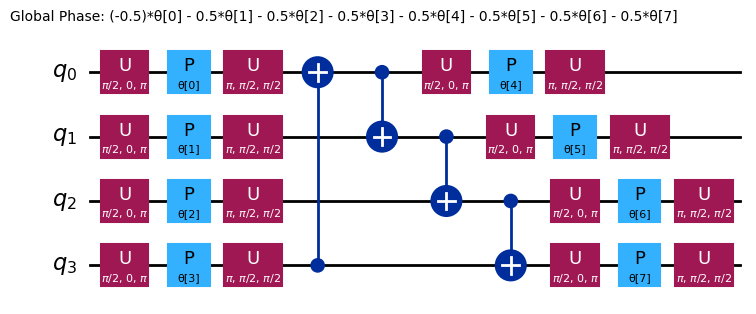

In [7]:
ansatz.decompose().draw('mpl')

<a id="ising-statevector"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.3 VQE with Statevector Estimator for Ising Hamiltonian

</h2>

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Defining Estimator</h3>

In [8]:
# Use StatevectorEstimator for exact simulation, which is a V2 primitive
estimator = StatevectorEstimator()

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Estimate the Ground State Energy: $min\langle \psi(\theta)|\hat{H}|\psi(\theta)\rangle $</h3>


In [9]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """
    Evaluate energy expectation value for given ansatz parameters.

    Parameters
    ----------
    params : ndarray
        Current ansatz parameters θ
    ansatz : QuantumCircuit
        Parameterized quantum circuit
    hamiltonian : SparsePauliOp
        Hamiltonian operator
    estimator : EstimatorV2
        Qiskit estimator primitive

    Returns
    -------
    float
        Estimated expectation value of the Hamiltonian
    """

    # Run estimator
    job = estimator.run([(ansatz, hamiltonian, params)])
    result = job.result()

    energy = float(result[0].data.evs)

    # Store optimization history
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params.copy()
    cost_history_dict["cost_history"].append(energy)

    # Optional logging (cleaner output)
    if cost_history_dict["iters"] % 5 == 0 and LOGGING:
        print(f"Iteration {cost_history_dict['iters']:4d} | Energy = {energy}")

    return energy

In [10]:
# Fix seed for reproducibility
np.random.seed(75)

Maxiter = 250
LOGGING  = True
# Initial guess of parameters
x0 = 2 * np.pi * np.random.random(num_params)

# Dictionary to store optimization history
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

# Run classical optimizer
res = minimize(
    cost_func,
    x0,
    args=(ansatz, Hamiltonian, estimator),
    method="L-BFGS-B",   # You can use other Optimization methods like 'COBYLA', 'Powell', 'Nelder-Mead', 'SPSA'
    options={
        "maxiter": Maxiter,
        "disp": True
    },
)

print("\nOptimization Result")
print(res)

/tmp/ipykernel_3738/1194014221.py:17: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Iteration    5 | Energy = -0.35218116761259444
Iteration   10 | Energy = -0.6565283701145357
Iteration   15 | Energy = -0.6565283701145355
Iteration   20 | Energy = -0.7874351207454383
Iteration   25 | Energy = -0.7874351219151617
Iteration   30 | Energy = -0.9402698254580159
Iteration   35 | Energy = -0.9402698274198857
Iteration   40 | Energy = -0.9970045007979793
Iteration   45 | Energy = -0.9970045007690762
Iteration   50 | Energy = -1.0294845281346658
Iteration   55 | Energy = -0.6759640932578753
Iteration   60 | Energy = -0.6759640932578751
Iteration   65 | Energy = -1.1194237837928935
Iteration   70 | Energy = -1.1194237819116746
Iteration   75 | Energy = -0.47413797380078215
Iteration   80 | Energy = -0.47413797379334616
Iteration   85 | Energy = -1.1504935666056706
Iteration   90 | Energy = -1.150493567633628
Iteration   95 | Energy = -1.2111302456878166
Iteration  100 | Energy = -1.2811780965082857
Iteration  105 | Energy = -1.281178096508285
Iteration  110 | Energy = -1.4093

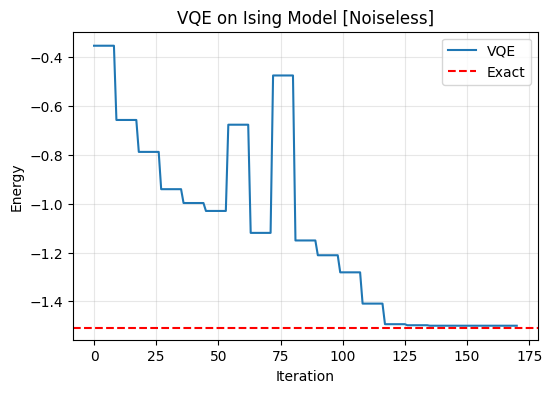

In [11]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(cost_history_dict["cost_history"], label="VQE")
ax.axhline(gs_energy, linestyle="--", color="red", label="Exact")

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title("VQE on Ising Model [Noiseless]")

ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">
Use of VQE pre-build function
</h3>

<p style="font-family:'Times New Roman', Times, serif; font-size:15px;">
The <code>qiskit_algorithms</code> package provides an implementation of the <b>Variational Quantum Eigensolver (VQE)</b>, which allows us to solve eigenvalue problems
in a much simpler and structured way.
</p>

In [12]:
from qiskit_algorithms.utils import algorithm_globals
algorithm_globals.random_seed = 75

counts = []
values = []
params = []
# Running the VQE simulation
def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)

repulsion = 0 # Initializing repulsion variable

vqe = VQE(estimator,
           ansatz,
           optimizer=L_BFGS_B(maxiter=250),
           callback=store_intermediate_result
          )
result = vqe.compute_minimum_eigenvalue(Hamiltonian)

print(result)

print(f"VQE on Aer qasm simulator (without noise): {result.eigenvalue.real:.5f}")
print(f"Delta from reference energy value is {(result.eigenvalue.real - gs_energy):.5f}")


{   'aux_operators_evaluated': None,
    'cost_function_evals': 126,
    'eigenvalue': np.float64(-1.499999999997852),
    'optimal_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x786b097e8860>,
    'optimal_parameters': {   ParameterVectorElement(θ[0]): np.float64(-3.1415930474253613),
                              ParameterVectorElement(θ[1]): np.float64(-6.283183687538699),
                              ParameterVectorElement(θ[2]): np.float64(-9.747152493438953e-07),
                              ParameterVectorElement(θ[3]): np.float64(3.1415907173647515),
                              ParameterVectorElement(θ[4]): np.float64(5.443304277111597),
                              ParameterVectorElement(θ[5]): np.float64(3.160316327694177),
                              ParameterVectorElement(θ[6]): np.float64(5.364110788814739),
                              ParameterVectorElement(θ[7]): np.float64(5.620729577996491)},
    'optimal_point': array([-3.14159305e+00, -6

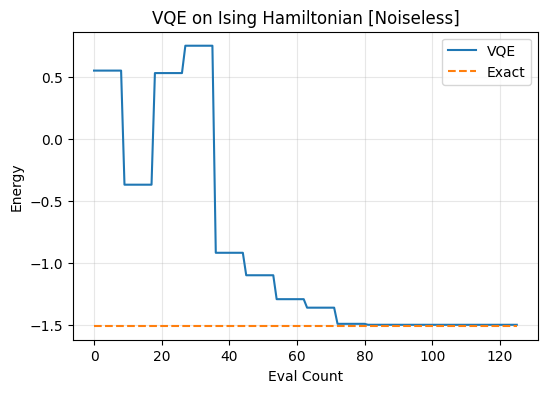

In [13]:
iterations = range(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, np.array(values) + repulsion, label='VQE')
plt.plot(iterations, (gs_energy + repulsion) * np.ones(len(values)), '--', label='Exact')

plt.xlabel("Eval Count")
plt.ylabel('Energy')
plt.title('VQE on Ising Hamiltonian [Noiseless]')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<a id="ising-aer"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.4 VQE with Aer Custom Noise Model for Ising Hamiltonian
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="font-size:15px;">
Real quantum hardware is affected by different sources of <b>noise</b> due to imperfect gates, environmental interactions, and measurement errors. To study how algorithms behave in realistic conditions, <b>Qiskit Aer</b> allows us to simulate noisy quantum circuits using configurable <b>noise models</b>.
</p>

<p style="font-size:15px;"><b>Common Noise Sources</b></p>

<ul style="font-size:15px;">
<li><b>Shot Noise</b> : Statistical fluctuations arising from finite measurement samples.</li>
<li><b>Depolarizing Error</b> : The qubit state randomly becomes a maximally mixed state.</li>


<li style="font-size:15px;"><b>Random Pauli Errors</b></li>

<ul style="font-size:15px;">
<li><b>Bit Flip Error</b> → X error ($|0\rangle \leftrightarrow |1\rangle)$</li>
<li><b>Phase Flip Error</b> → Z error (phase change)</li>
<li><b>Bit + Phase Flip</b> → Y error</li>
</ul>
</ul>

<p style="font-size:15px;">
A simple depolarizing noise channel can be written as ${\large \rho' = (1-p)\rho + p \frac{I}{4}\large} $
</p>

<p style="font-size:15px;">
where <b>p</b> represents the probability of error and <b>I</b> is the identity operator. In Qiskit, such noise channels can be implemented using the <code>qiskit_aer.noise</code> module and applied to quantum gates or measurements to emulate realistic quantum hardware behavior.
</p>

</div>

Number of qubits: 4
The Exact Ground State Energy is: -1.5075557618995328 
global phase: (-0.5)*θ[4] - 0.5*θ[5] - 0.5*θ[6] - 0.5*θ[7] - 0.5*θ[12] - 0.5*θ[13] - 0.5*θ[14] - 0.5*θ[15]
     ┌───────────┐┌─────────┐     ┌───────────┐ ┌──────────┐              »
q_0: ┤ R(θ[0],0) ├┤ P(θ[4]) ├──■──┤ R(θ[8],0) ├─┤ P(θ[12]) ├──────────────»
     ├───────────┤├─────────┤┌─┴─┐└───────────┘┌┴──────────┤ ┌──────────┐ »
q_1: ┤ R(θ[1],0) ├┤ P(θ[5]) ├┤ X ├──────■──────┤ R(θ[9],0) ├─┤ P(θ[13]) ├─»
     ├───────────┤├─────────┤└───┘    ┌─┴─┐    └───────────┘┌┴──────────┴┐»
q_2: ┤ R(θ[2],0) ├┤ P(θ[6]) ├─────────┤ X ├──────────■──────┤ R(θ[10],0) ├»
     ├───────────┤├─────────┤         └───┘        ┌─┴─┐    ├────────────┤»
q_3: ┤ R(θ[3],0) ├┤ P(θ[7]) ├──────────────────────┤ X ├────┤ R(θ[11],0) ├»
     └───────────┘└─────────┘                      └───┘    └────────────┘»
«                 
«q_0: ────────────
«                 
«q_1: ────────────
«     ┌──────────┐
«q_2: ┤ P(θ[14]) ├
«     ├──────────┤
«

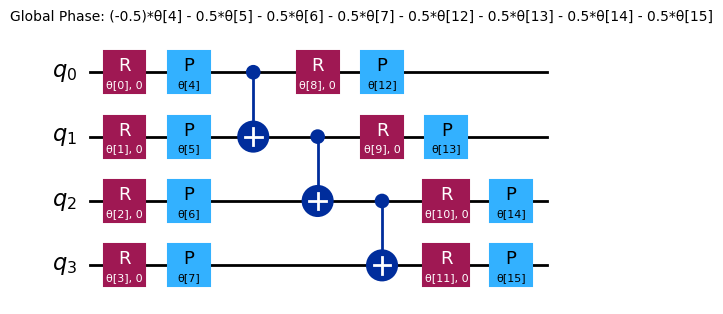

In [14]:
# Problem Defining
J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])
print(f"Number of qubits: {Hamiltonian.num_qubits}")

# Exact Solution (Exact Eigenvalue)
eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)   # Also can use NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
gs_energy = eigen_values.eigenvalues[0]
print(f"The Exact Ground State Energy is: {gs_energy} ")

iterations = 125

ansatz = n_local(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)
#ansatz = TwoLocal(Hamiltonian.num_qubits, rotation_blocks=['rx', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps = 1)  # Old version
#ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')

print(ansatz.decompose())
ansatz.decompose().draw("mpl")

In [15]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

seed = 75
algorithm_globals.random_seed = seed

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.01, 1), ["rx", "rz"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.05, 2), ["cx"]
)

print(noise_model)
noisy_estimator = AerEstimator(
    options={
            "backend_options": {"noise_model": noise_model},
            "run_options": {"shots": 4096}
            },
)

# re-start callback variables
counts = []
values = []

vqe.estimator = noisy_estimator

result_noise = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)

print(f"VQE on Aer qasm simulator (with noise): {result_noise.eigenvalue.real:.5f}")
print(f"Delta from reference energy value is {(result_noise.eigenvalue.real - gs_energy):.5f}")


NoiseModel:
  Basis gates: ['cx', 'id', 'rx', 'rz', 'sx']
  Instructions with noise: ['cx', 'rx', 'rz']
  All-qubits errors: ['rx', 'rz', 'cx']
VQE on Aer qasm simulator (with noise): -1.23694
Delta from reference energy value is 0.27062


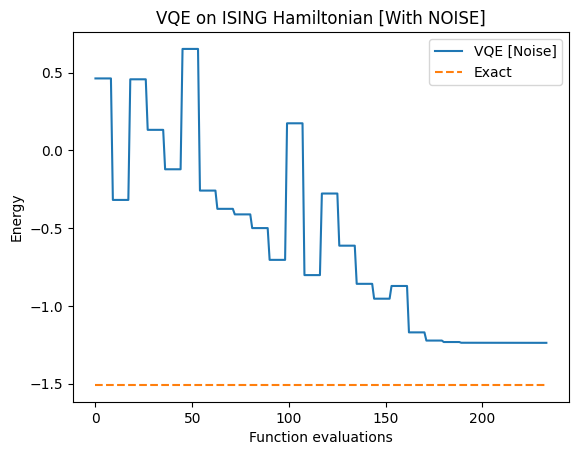

In [16]:
# plot
plt.plot(values)
plt.plot(gs_energy*np.ones(len(values)), '--')
plt.xlabel("Function evaluations")
plt.ylabel('Energy')
plt.legend(['VQE [Noise]', 'Exact'])
plt.title('VQE on ISING Hamiltonian [With NOISE]')
plt.show()

<a id="ising-fake"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">1.5 VQE on Fake Backend for Ising Hamiltonian
</h2>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
In Qiskit, a <b>FakeBackend</b> is a software model that mimics the behavior of a real IBM Quantum device. Instead of running a circuit on actual quantum hardware, the
simulation is performed locally on your computer using <b>Qiskit Aer</b>, while still incorporating the hardware properties and noise characteristics of a real device.
</p>

<p style="font-family:'Times New Roman', Times, serif; font-size:16px;">
This allows researchers and students to test and analyze quantum circuits under
<b>realistic hardware conditions</b> without needing access to an actual quantum computer.
</p>

In [17]:
from qiskit_ibm_runtime.fake_provider import (FakeManilaV2, FakeLimaV2, FakeJakartaV2, FakeAthensV2, FakeBelemV2,
                                                FakeBogotaV2, FakeCasablancaV2, FakeNairobiV2, FakePerth, FakeOslo)

J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],[J, J, J, h, h, h, h])

eigen_values = NumPyEigensolver().compute_eigenvalues(Hamiltonian)
#eigen_values = np.linalg.eigh(Hamiltonian)
gs_energy = eigen_values.eigenvalues[0]
print(f"The Exact Ground State Energy is: {gs_energy} ")

# The ansatz for the VQE
#ansatz = TwoLocal(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular')


# Fake backend
backend_choice = "Manila"

backend_map = {
    "Manila": FakeManilaV2,
    "Lima": FakeLimaV2,
    "Jakarta": FakeJakartaV2,
    "Athens": FakeAthensV2,
    "Belem": FakeBelemV2,
    "Bogota": FakeBogotaV2,
    "Casablanca": FakeCasablancaV2,
    "Nairobi": FakeNairobiV2,
    "Perth": FakePerth,
    "Oslo": FakeOslo
}

fake_backend = backend_map[backend_choice]()

# Noise model
noise_model = NoiseModel.from_backend(fake_backend)
print(f"Backend Used: {backend_choice}")
print(noise_model)

# Estimator
fake_estimator = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": fake_backend.coupling_map,
            "basis_gates": fake_backend.operation_names,
        },
        "run_options": {"shots": 4096}}
)

# Transpile ansatz ONCE
# tqc = transpile(ansatz, fake_backend)

# re-start callback variables
counts = []
values = []

vqe.estimator = fake_estimator

result_fake = vqe.compute_minimum_eigenvalue(operator=Hamiltonian)


print(f"VQE on Aer qasm simulator (on FakeBackend): {result_fake.eigenvalue.real:.5f}")
print(f"Delta from reference energy value is {(result_fake.eigenvalue.real - gs_energy):.5f}")


The Exact Ground State Energy is: -1.50755576189954 
Backend Used: Manila
NoiseModel:
  Basis gates: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['measure', 'reset', 'x', 'id', 'cx', 'sx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
VQE on Aer qasm simulator (on FakeBackend): -1.43902
Delta from reference energy value is 0.06853


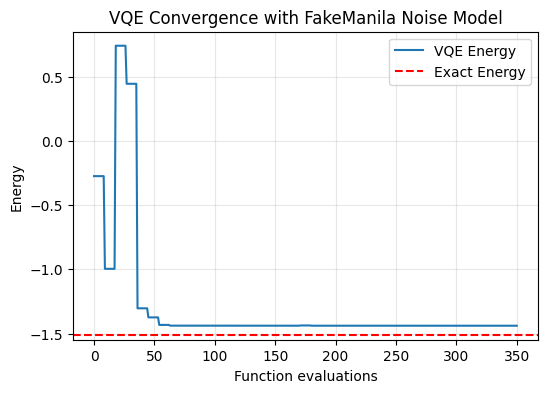

In [18]:
iterations = np.arange(len(values))

plt.figure(figsize=(6,4))

plt.plot(iterations, values, label="VQE Energy")
plt.axhline(gs_energy, linestyle="--", color="red", label="Exact Energy")

plt.xlabel("Function evaluations")
plt.ylabel("Energy")
plt.title(f"VQE Convergence with Fake{backend_choice} Noise Model")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<hr style="border:1px solid #cfe0ff;margin:15px 0;">
<h2 style="text-align:center;color:red; font-weight:bold;font-family:'Times New Roman', Times, serif;">PART B$\quad$ |$\quad $VQE for $H_2$ Molecule</h2>
<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<a id="h2-hamiltonian"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">
2.1 Constructing Molecular Hamiltonian
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<p style="text-align:right; font-size:17px"><a href="#index">[⬆️ Back to Contents]</a></p>
<p style="font-size:17px;">
One of the most important applications of quantum computing is the simulation of <b>molecular electronic structure</b>. Classical algorithms often struggle with solving the many-body Schrödinger equation for molecules because the size of the Hilbert space grows exponentially with the number of electrons.
</p>

<p style="font-size:17px;">
For a molecular system such as the hydrogen molecule (<b>$H_2$</b>), the electronic structure problem can be written in the <b>second-quantized form</b> as
</p>

$$ {\Large H = \sum_{pq} h_{pq} a_p^\dagger a_q
+ \frac{1}{2} \sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s \Large} $$

<p style="font-size:17px;">
where
</p>

<ul style="font-size:16px;">
<li><b>$a_p^\dagger$</b> and <b>$a_p$</b> are fermionic creation and annihilation operators</li>
<li><b>$h_{pq}$</b> are one-electron integrals describing kinetic energy and nuclear attraction</li>
<li><b>$h_{pqrs}$</b> are two-electron integrals representing electron-electron interactions</li>
</ul>

<p style="font-size:17px;">
To run this Hamiltonian on a quantum computer, the fermionic operators must be mapped to qubit operators. This is typically done using transformations such as the <b>Jordan-Wigner</b> or <b>Bravyi-Kitaev</b> mapping.
After this mapping, the Hamiltonian can be written as a sum of Pauli operators.
</p>

<p style="font-size:17px;">
For the hydrogen molecule in a minimal basis (STO-3G), the qubit Hamiltonian can be expressed as
</p>

$$
{\Large
H = c_0 I + c_1 Z_0 + c_2 Z_1 + c_3 Z_0Z_1 + c_4 X_0X_1 + c_5 Y_0Y_1
\Large}
$$

<p style="font-size:17px;">
where the coefficients <b>$c_i$</b> depend on the inter-nuclear distance of the hydrogen atoms. This Hamiltonian can then be used in the <b>VQE algorithm</b> to approximate the ground state energy of the molecule.
</p>

<p style="font-size:17px;">
In the following sections, we will construct this Hamiltonian using <b>Qiskit Nature</b> and use VQE to estimate the ground state energy of the $H_2$ molecule.
</p>

</div>

In [19]:
!pip install "qiskit-nature[pyscf]" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.8 MB/s eta 0:00:00


In [20]:
# Import necessary libraries
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorEstimator # Changed from Estimator
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms import VQE
from qiskit_algorithms.eigensolvers import NumPyEigensolver
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock, UCC

import matplotlib.pyplot as plt
import numpy as np

<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Defining Problem</h3>

In [21]:
# Molecular Geometry
driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 0.7")

# The Classical Hamiltonian
problem = driver.run()

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">
<h4 style="color:blue; font-weight:bold">
What <code style="font-size:15px">PySCFDriver.run()</code> returns?
</h4>

<p style="font-size:17px;">
In <b>Qiskit Nature</b>, molecular electronic structure problems are typically generated using classical quantum chemistry packages such as <b>PySCF</b>. The interface between PySCF and Qiskit Nature is provided by the <code style="font-size:14px">PySCFDriver</code>.
</p>

<p style="font-size:17px;">
When the method <code style="font-size:14px">PySCFDriver.run()</code> is executed, it returns an object of type <code style="font-size:14px">ElectronicStructureProblem</code>. This object acts as a central
container that stores all physically relevant information about the molecular electronic structure problem.
</p>

<p style="font-size:17px;">
The attribute <code style="font-size:14px">problem.hamiltonian</code> is of type <code style="font-size:14px">ElectronicEnergy</code> and represents the electronic Hamiltonian of the molecular system.
</p>

<p style="font-size:17px;">
In first quantization, the electronic Hamiltonian is given by
</p>

$$ {\large H_{\text{elec}} = \sum_{i=1}^{N} \left( -\frac{1}{2}\nabla_i^2 - \sum_{A} \frac{Z_A}{|\mathbf{r}_i - \mathbf{R}_A|}\right) + \sum_{i<j}\frac{1}{|\mathbf{r}_i - \mathbf{r}_j|}\large} $$

<p style="font-size:17px;">
For quantum computing applications, it is more convenient to express this Hamiltonian in <b>second quantization</b>. In this representation the Hamiltonian becomes
</p>

$${\large H_{\text{elec}} = \sum_{pq} h_{pq} a_p^\dagger a_q + \frac{1}{2}\sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s \large}$$

<p style="font-size:17px;">
The Hamiltonian above describes only the <b>electronic energy</b>. To obtain the total molecular energy, the <b>nuclear repulsion energy</b> must also be added:
</p>

$${\large E_{\text{total}} = E_{\text{elec}} + V_{nn}\large}$$

<p style="font-size:17px;">
At this stage the Hamiltonian is still expressed in terms of <b>fermionic operators</b>. Since quantum computers operate on qubits, the fermionic Hamiltonian must be mapped to a qubit operator using transformations such as the <b>Jordan–Wigner</b> or <b>Bravyi–Kitaev</b> mapping. The resulting qubit Hamiltonian can then be used as input to algorithms such as the <b>Variational Quantum Eigensolver (VQE)</b>.
</p>

</div>

In [22]:
hamiltonian = problem.hamiltonian

# Mapping the Hamiltonian into Qubit Space
second_q_h = hamiltonian.second_q_op()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(second_q_h)
print(hamiltonian_op)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.79804642+0.j,  0.17771287+0.j, -0.24274281+0.j,  0.12293305+0.j,
  0.17771287+0.j,  0.17059738+0.j, -0.24274281+0.j,  0.16768319+0.j,
  0.04475014+0.j,  0.04475014+0.j,  0.04475014+0.j,  0.04475014+0.j,
  0.16768319+0.j,  0.17627641+0.j,  0.12293305+0.j])


<h3 style="color:green; font-family:'Times New Roman', Times, serif; font-weight:bold">Exact Ground State Energy</h3>

In [23]:
# Nuclear Repulsion Energy
repulsion = hamiltonian.constants.get('nuclear_repulsion_energy')
print("Repulsion Energy : ", repulsion)

Repulsion Energy :  0.7559674441714287


In [25]:
from qiskit_algorithms import NumPyMinimumEigensolver

# Exact Energy
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
exact = exact.eigenvalue.real
print("Ground State Energy : ", exact+repulsion)

Ground State Energy :  -1.1361894540659234


<a id="h2-ansatz"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.2 Ansatz for Molecular Systems
</h2>


In [26]:
ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
# ansatz = UCC(2, (1, 1), excitations='sd', qubit_mapper=JordanWignerMapper(), initial_state=HartreeFock(2,(1,1),JordanWignerMapper()))
# ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')

<a id="h2-statevector"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.3 VQE with Statevector Estimator (Noise Free)  for $H_2$
</h2>
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>


In [27]:
# Estimator
estimator = StatevectorEstimator() # Changed from Estimator()

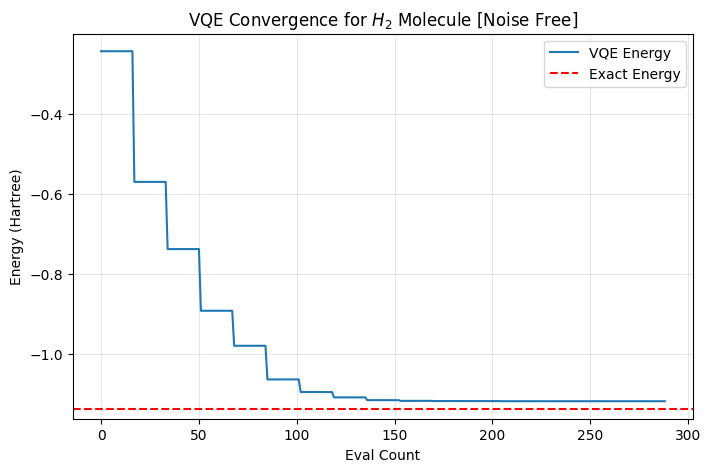

In [28]:
# Running the VQE simulation

counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator,
    ansatz,
    optimizer=L_BFGS_B(maxiter=200),
    callback=store_intermediate_result
)

result_ideal = vqe.compute_minimum_eigenvalue(hamiltonian_op)

# Convert to total energy by adding nuclear repulsion
vqe_energy = np.array(values) + repulsion
exact_energy = exact + repulsion


# Plotting Results
plt.figure(figsize=(8,5))

plt.plot(range(len(vqe_energy)), vqe_energy, label='VQE Energy')

plt.axhline(exact_energy, linestyle='--', color='red', label='Exact Energy')

plt.xlabel('Eval Count')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for $H_2$ Molecule [Noise Free]')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<a id="h2-aer"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.4 VQE with Custom Noise Model  for $H_2$
</h2>
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>

Ground State Energy :  -1.1373060357534022
Final Energy (with noise): -1.118628 Hartree
ΔE Error (with noise): 0.018678 Hartree


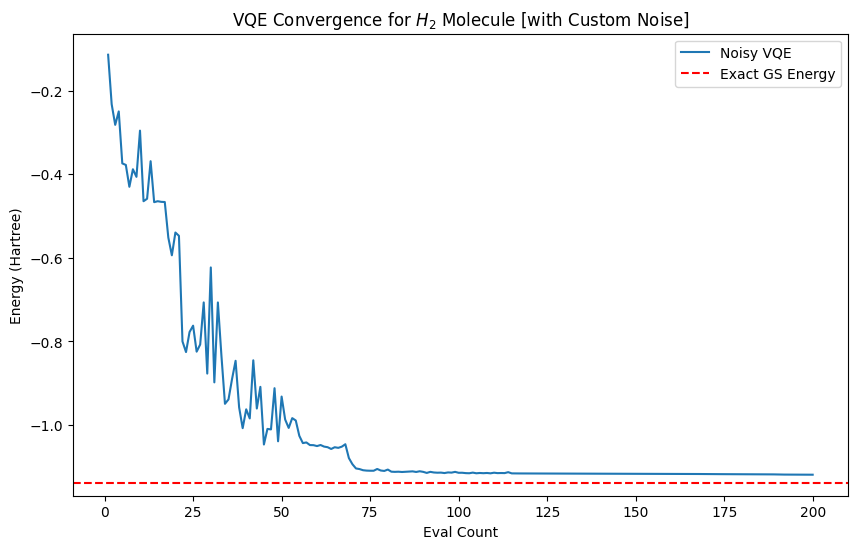

In [29]:
# 1. Setup Molecule and Hamiltonian
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(problem.hamiltonian.second_q_op())
repulsion = problem.hamiltonian.constants.get('nuclear_repulsion_energy')

# 2. Exact Solution
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
gs_energy = exact.eigenvalue.real +repulsion
print("Ground State Energy : ", gs_energy)

# 2. Setup Ansatz
ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
# ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')
# ansatz = UCC(num_spatial_orbitals=2, num_particles=(1, 1), excitations='sd', qubit_mapper=mapper, initial_state=HartreeFock(2, (1, 1), mapper) )

ansatz = ansatz.decompose(reps=2)

# 3. Create Noise Model
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.002, 2), ["cx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.001, 1), ["rz", "sx", "x", "ry"])

# 4. Define Estimator
estimator_noise = AerEstimator(options={"backend_options":{"noise_model": noise_model},
                                   "run_options": {"shots": 4096}
                                 }
)

#5. Running VQE
counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator_noise,
    ansatz,
    optimizer=COBYLA(maxiter=200),
    callback=store_intermediate_result
)

result_noise = vqe.compute_minimum_eigenvalue(hamiltonian_op)
# print(result_noise)

# 6. Final Energy and Plot
final_energy = result_noise.optimal_value + repulsion
print(f"Final Energy (with noise): {final_energy:.6f} Hartree")
print(f"ΔE Error (with noise): {final_energy-gs_energy:.6f} Hartree")

plt.figure(figsize=(10, 6))
plt.plot(counts, np.array(values) + repulsion, label='Noisy VQE')
plt.axhline(y=gs_energy, color='r', linestyle='--', label='Exact GS Energy')
plt.xlabel('Eval Count')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for $H_2$ Molecule [with Custom Noise]')
plt.legend()
plt.show()

<a id="h2-fake"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">2.5 VQE on FakeBackend for $H_2$
</h2>
<p style="text-align:right; font-size:15px"><a href="#index">[⬆️ Back to Contents]</a></p>

Ground State Energy :  -1.1373060357533977
Backend Used: Manila
NoiseModel:
  Basis gates: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['measure', 'reset', 'x', 'id', 'cx', 'sx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('cx', (0, 1)), ('cx', (1, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Final Energy (with noise): -0.605678 Hartree
ΔE Error (with noise): 0.531628 Hartree


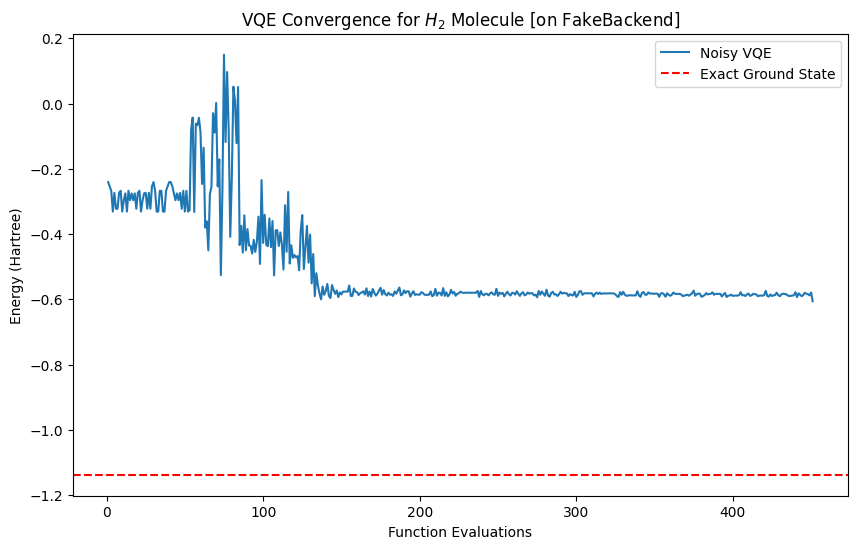

In [30]:
# 1. Setup Molecule and Hamiltonian
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(problem.hamiltonian.second_q_op())
repulsion = problem.hamiltonian.constants.get('nuclear_repulsion_energy')

# 2. Exact Solution
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
gs_energy = exact.eigenvalue.real +repulsion
print("Ground State Energy : ", gs_energy)

# 2. Setup Ansatz
# ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
#ansatz = efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "ry"], reps = 1, entanglement = 'circular')
ansatz = UCC(num_spatial_orbitals=2, num_particles=(1, 1), excitations='sd', qubit_mapper=mapper, initial_state=HartreeFock(2, (1, 1), mapper) )

ansatz = ansatz.decompose(reps=2)

# 3. Create Noise Model
# Fake backend
backend_choice = "Manila"
backend_map = {
    "Manila": FakeManilaV2,
    "Jakarta": FakeJakartaV2,
    "Nairobi": FakeNairobiV2,
}
fake_backend = backend_map[backend_choice]()
# Noise model
noise_model = NoiseModel.from_backend(fake_backend)
print(f"Backend Used: {backend_choice}")
print(noise_model)

# 4. Define Estimator
estimator_fake = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model,
            "coupling_map": fake_backend.coupling_map,
            "basis_gates": fake_backend.operation_names,
        },
        "run_options": {"shots": 4096}}
)


#5. Running VQE
counts = []
values = []
params = []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    params.append(parameters)


vqe = VQE(
    estimator_fake,
    ansatz,
    optimizer=SPSA(maxiter=200),
    callback=store_intermediate_result
)

result_noise = vqe.compute_minimum_eigenvalue(hamiltonian_op)
# print(result_noise)

# 6. Final Energy and Plot
final_energy = result_noise.optimal_value + repulsion
print(f"Final Energy (with noise): {final_energy:.6f} Hartree")
print(f"ΔE Error (with noise): {final_energy-gs_energy:.6f} Hartree")

plt.figure(figsize=(10, 6))
plt.plot(counts, np.array(values) + repulsion, label='Noisy VQE')
plt.axhline(y=gs_energy, color='r', linestyle='--', label='Exact Ground State')
plt.xlabel('Function Evaluations')
plt.ylabel('Energy (Hartree)')
plt.title('VQE Convergence for $H_2$ Molecule [on FakeBackend]')
plt.legend()
plt.show()

<a id="qpu_execution"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">3.1 Running on Real Quantum Computer
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
">

<p style="text-align:right;">
<a href="#index">[⬆️ Back to Contents]</a>
</p>

<p style="font-size:17px;">
So far we executed the <b>Variational Quantum Eigensolver (VQE)</b> on ideal
and noisy simulators. While simulators help us understand algorithm behavior,
the ultimate goal is to run the algorithm on a <b>real quantum processor</b>.
</p>

<p style="font-size:17px;">
In this section we will execute the VQE algorithm on real hardware available
through the <b>IBM Quantum cloud platform</b>. The workflow involves connecting
to the IBM Quantum service, selecting an available quantum processor, and
running the VQE optimization loop using the hardware backend.
</p>

</div>



<a id="setting-ibm-cloud"></a>
<div style="
font-family:'Times New Roman', Times, serif; font-size:17px;
line-height:1.6;
">
<h3 style="font-weight:bold; color:red;">Set up your IBM Cloud account</h3>

We must set up an IBM Cloud account in order to execute quantum circuits on real hardware. First go to [IBM Quantum Platform](https://quantum.cloud.ibm.com/) and Sign in to your existing account or Create an IBM Cloud Account.


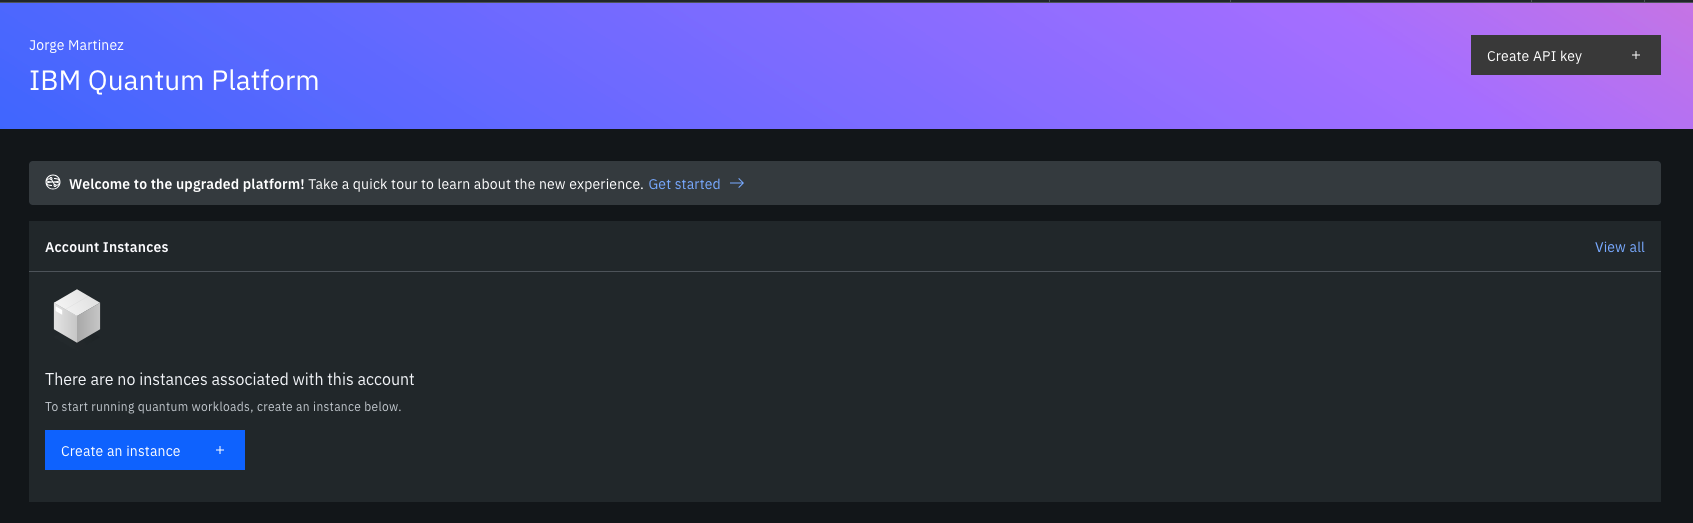



<p>
After logging in, navigate to the <b>Account Settings</b> page and copy your
<b>API Token</b>. This token allows Qiskit to securely connect to your IBM
Quantum account from your local Python environment.
</p>

<p>
Once the API token is obtained, we can save it locally using
<b>Qiskit Runtime</b>. This step only needs to be performed once.
</p>

In [31]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Save your API token once
QiskitRuntimeService.save_account(
    token="Your API Key"

)

Ground State Energy :  -1.1373060357534004
This circuit has  16 parameters


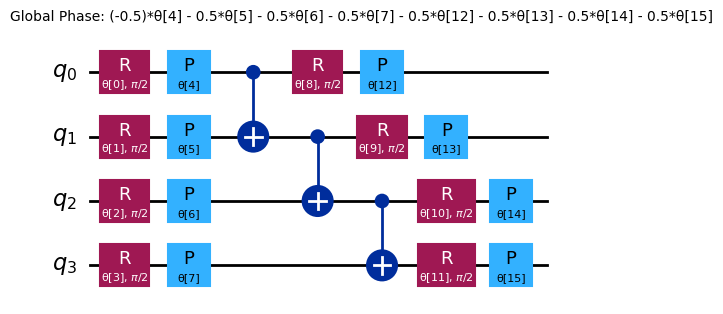

In [32]:
# 1. Setup Molecule and Hamiltonian
driver = PySCFDriver(atom="H 0 0 0; H 0 0 0.735")
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian_op = mapper.map(problem.hamiltonian.second_q_op())
repulsion = problem.hamiltonian.constants.get('nuclear_repulsion_energy')

# 2. Exact Solution
exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_op)
gs_energy = exact.eigenvalue.real +repulsion
print("Ground State Energy : ", gs_energy)

# 2. Setup Ansatz
ansatz = n_local(num_qubits=4, rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.decompose().draw("mpl", style="iqp")

The ansatz was written using familiar gates, but our circuit must be transpiled to make use of the basis gates that can be implemented on each quantum computer. We select the least busy backend.

In [33]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-14 22:06:47,372: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-14 22:06:47,856: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-14 22:06:49,904: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


We can now transpile our circuit for this hardware and visualize our transpiled ansatz.

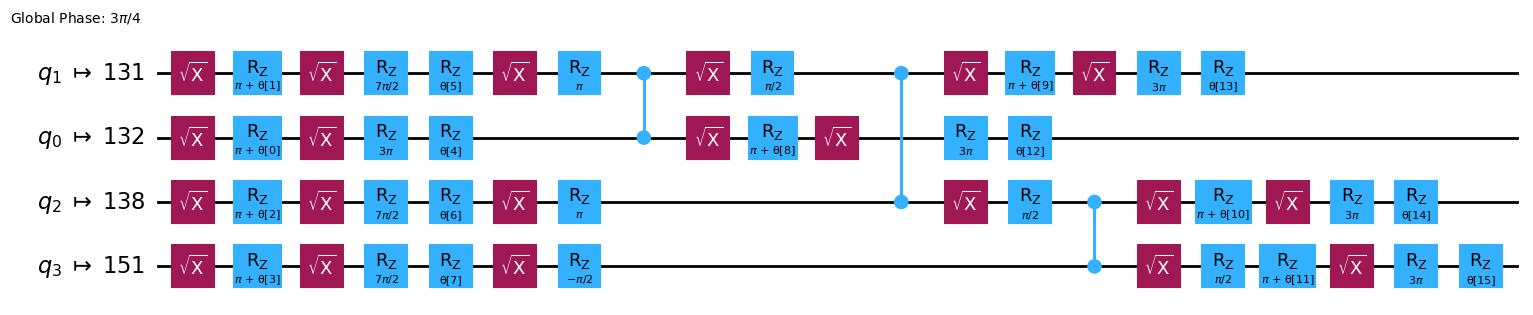

In [34]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

> Note that the gates used have changed, and the qubits in our abstract circuit have been mapped to differently-numbered qubits on the quantum computer. We must map our Hamiltonian identically in order for our results to be meaningful.

In [35]:
hamiltonian_isa = hamiltonian_op.apply_layout(layout=ansatz_isa.layout)

In [47]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy


cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
# Initial values of parameters
x0 = 2 * np.pi * np.random.random(num_params)

In [48]:
# runtime imports
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)
estimator.options.default_shots = 256

res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 30},
)

Iters. done: 1 [Current cost: -0.7784787535332517]
Iters. done: 2 [Current cost: -0.5224078229151401]
Iters. done: 3 [Current cost: -0.7170080315715934]
Iters. done: 4 [Current cost: -0.8115536956821233]
Iters. done: 5 [Current cost: -0.8003272306160715]
Iters. done: 6 [Current cost: -0.7643290359670394]
Iters. done: 7 [Current cost: -0.810884706301952]
Iters. done: 8 [Current cost: -0.8594893670444672]
Iters. done: 9 [Current cost: -0.9901289902635312]
Iters. done: 10 [Current cost: -0.9631124080937817]
Iters. done: 11 [Current cost: -0.781654750592433]
Iters. done: 12 [Current cost: -0.8726591362165639]
Iters. done: 13 [Current cost: -0.9222298775384742]
Iters. done: 14 [Current cost: -1.0271100350633502]
Iters. done: 15 [Current cost: -0.9864859875717717]
Iters. done: 16 [Current cost: -0.9715116051922358]
Iters. done: 17 [Current cost: -0.963607340171636]
Iters. done: 18 [Current cost: -1.293749865257501]
Iters. done: 19 [Current cost: -1.4068545995732076]
Iters. done: 20 [Current 

In [49]:
final_energy = res.fun + repulsion

print("\nOptimization finished")
print("Optimal parameters:", res.x)
print("Final VQE energy:", final_energy)
print("Exact energy:", gs_energy)
print("Energy error:", abs(final_energy - gs_energy))


Optimization finished
Optimal parameters: [ 3.19241416  5.67328005  6.15116139  4.27848515  5.11513388  0.48381804
  2.70086367  5.91114694  5.11638175  2.85335065 -0.41592513  1.56075064
  2.14343764  5.17082884  5.55101954  4.06625925]
Final VQE energy: -0.9057068487222389
Exact energy: -1.1373060357534004
Energy error: 0.23159918703116145


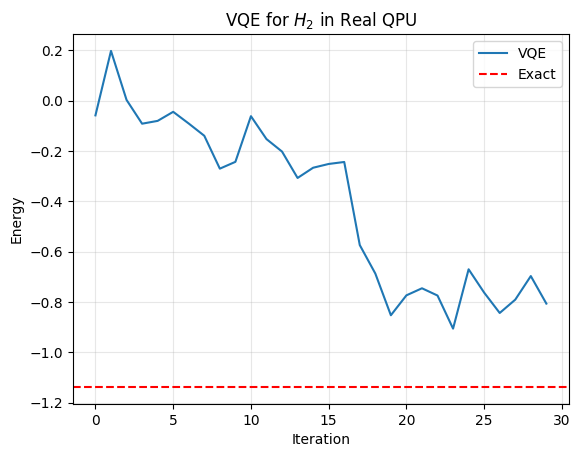

In [53]:
fig, ax = plt.subplots()

# Define the constant function
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"]+repulsion, label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.axhline(gs_energy, linestyle="--", color="red", label="Exact")

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title("VQE for $H_2$ in Real QPU")

ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

<a id="ising-compare"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">3.2 Comparisons over different parameters
</h2>
<p style="text-align:right;">
<a href="#index">[⬆️ Back to Contents]</a>
</p>


In [59]:
import time

J=0.5; h = 0.1*J
Hamiltonian = SparsePauliOp(
    ['ZZII','IZZI','IIZZ','XIII','IXII','IIXI','IIIX'],
    [J,J,J,h,h,h,h]
)

algorithm_globals.random_seed = 75

gs_energy = NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=Hamiltonian).eigenvalue.real
print("Exact ground state energy:", gs_energy)

ansatz_list = {
    "EfficientSU2": efficient_su2(Hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], reps = 1, entanglement = 'circular'),
    "NLocal": n_local(Hamiltonian.num_qubits, rotation_blocks=['ry','rz'], entanglement_blocks='cx', reps=1),
    "RealAmplitudes": real_amplitudes(Hamiltonian.num_qubits, reps=1)
}

optimizers = [COBYLA(maxiter=200), L_BFGS_B(maxiter=200), SPSA(maxiter=200)]

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01,1), ["rx","rz","ry"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05,2), ["cx"])

simulators = {
"noise_free": AerEstimator(options={"run_options": {"shots": 4096}}),
"custom_noise": AerEstimator(options={"backend_options": { "noise_model": noise_model}, "run_options": {"shots": 4096}}),
"fake_jakarta": AerEstimator(options={"backend_options": { "noise_model": NoiseModel.from_backend(FakeJakartaV2()),
                                                           "coupling_map": fake_backend.coupling_map, "basis_gates": fake_backend.operation_names,},
                                      "run_options": {"shots": 4096}}),
"fake_manila": AerEstimator(options={"backend_options": { "noise_model": NoiseModel.from_backend(FakeManilaV2()),
                                                           "coupling_map": fake_backend.coupling_map, "basis_gates": fake_backend.operation_names,},
                                      "run_options": {"shots": 4096}})
}

results = []
convergence_data = {}

for ansatz_name, ansatz in ansatz_list.items():
    convergence_data[ansatz_name] = {}
    for sim_type, estimator in simulators.items():
        convergence_data[ansatz_name][sim_type] = {}
        for optimizer in optimizers:
            print( "\rAnsatz: {} | Estimator: {} | Optimizer: {}      ".format( ansatz_name, sim_type, type(optimizer).__name__),end="")
            counts=[]
            values=[]
            def callback(eval_count, parameters, mean, std):
                counts.append(eval_count)
                values.append(mean)
            start=time.time()
            vqe=VQE(estimator, ansatz, optimizer, callback=callback )
            result=vqe.compute_minimum_eigenvalue( operator=Hamiltonian )
            end=time.time()

            final_energy=result.eigenvalue.real
            delta=abs(final_energy-gs_energy)

            convergence_data[ansatz_name][sim_type][type(optimizer).__name__] = {
                "counts": np.array(counts),
                "values": np.array(values)
            }

            results.append({
                "Ansatz":ansatz_name,
                "Estimator":sim_type,
                "Optimizer":type(optimizer).__name__,
                "Final Energy":final_energy,
                "ΔE Error":delta,
                "Time (s)":end-start
            })

Exact ground state energy: -1.5075557618995372
Ansatz: RealAmplitudes | Estimator: fake_manila | Optimizer: SPSA      

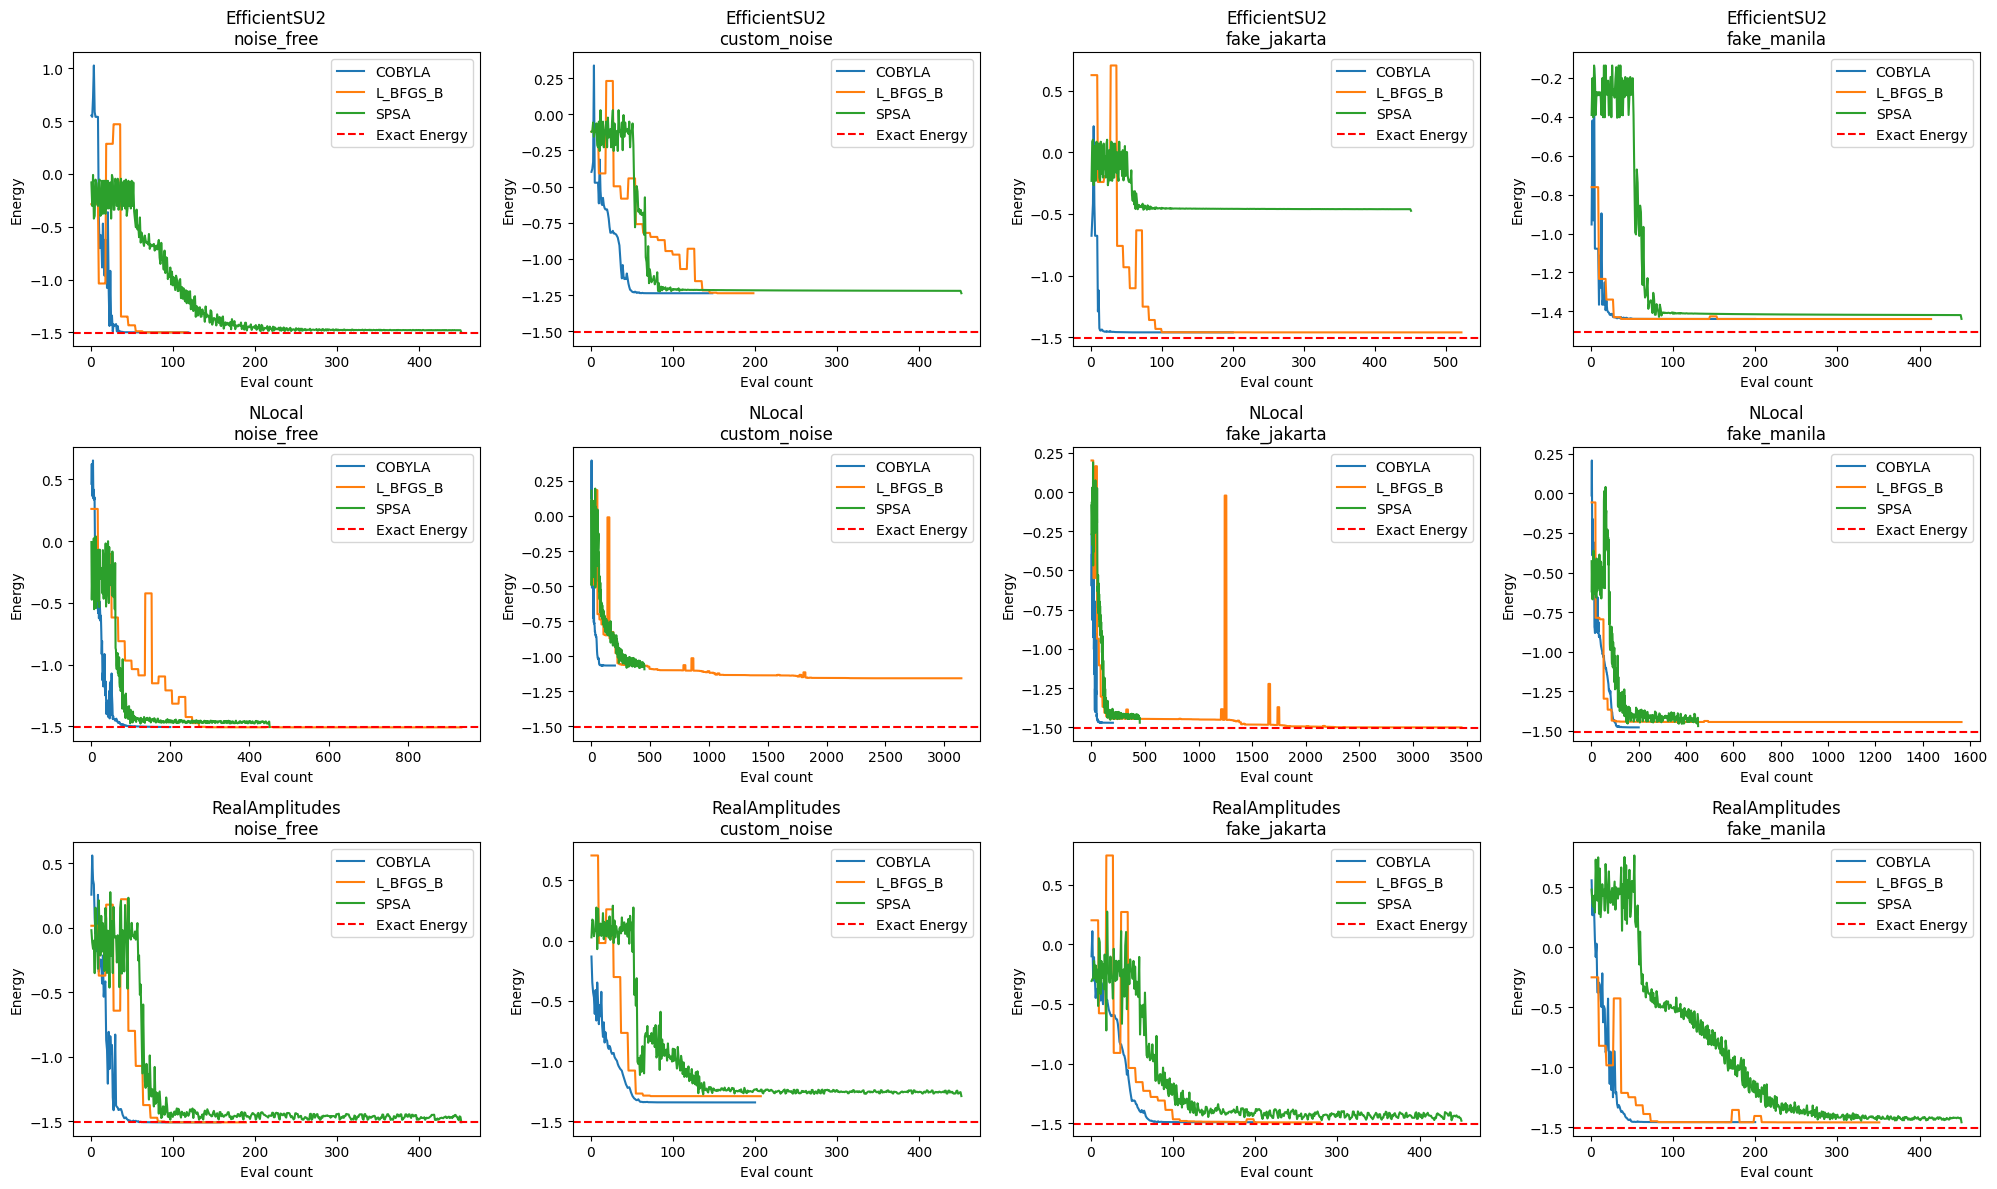

In [60]:
ansatz_names = list(ansatz_list.keys())
sim_names = list(simulators.keys())

fig, axes = plt.subplots(3, 4, figsize=(20,12))

for i, ansatz_name in enumerate(ansatz_names):
    for j, sim_name in enumerate(sim_names):

        ax = axes[i, j]

        for optimizer in optimizers:

            opt_name = type(optimizer).__name__

            data = convergence_data[ansatz_name][sim_name][opt_name]

            ax.plot(
                data["counts"],
                data["values"],
                label=opt_name
            )
        ax.axhline(gs_energy, linestyle="--", color="red", label="Exact Energy")
        ax.set_title(f"{ansatz_name}\n{sim_name}")
        ax.set_xlabel("Eval count")
        ax.set_ylabel("Energy")
        ax.legend()

plt.tight_layout()
plt.show()

In [61]:
!pip install rich -q

In [62]:
from rich.table import Table
from rich.console import Console
import pandas as pd

console = Console()

# Convert results list to dataframe
df = pd.DataFrame(results)
# pick the row with minimum ΔE Error for each Ansatz + Simulator pair
best_df = df.loc[
    df.groupby(["Ansatz", "Estimator"])["ΔE Error"].idxmin()
].sort_values(["Ansatz", "Estimator"])

console = Console()

table = Table(title="Best VQE Configuration per Ansatz & Simulator")

table.add_column("Ansatz", style="cyan", no_wrap=True)
table.add_column("Estimator", style="magenta")
table.add_column("Best Optimizer", style="green")
table.add_column("Final Energy", justify="right")
table.add_column("ΔE Error", justify="right")
table.add_column("Time (s)", justify="right")

for _, row in best_df.iterrows():
    table.add_row(
        row["Ansatz"],
        row["Estimator"],
        row["Optimizer"],
        f"{row['Final Energy']:.8f}",
        f"{row['ΔE Error']:.8f}",
        f"{row['Time (s)']:.3f}"
    )

console.print(table)

                      Best VQE Configuration per Ansatz & Simulator                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Ansatz         ┃ Estimator    ┃ Best Optimizer ┃ Final Energy ┃   ΔE Error ┃ Time (s) ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ EfficientSU2   │ custom_noise │ SPSA           │  -1.23693660 │ 0.27061917 │    1.388 │
│ EfficientSU2   │ fake_jakarta │ L_BFGS_B       │  -1.46055681 │ 0.04699895 │   48.746 │
│ EfficientSU2   │ fake_manila  │ L_BFGS_B       │  -1.43902449 │ 0.06853127 │   38.772 │
│ EfficientSU2   │ noise_free   │ L_BFGS_B       │  -1.50000000 │ 0.00755576 │    0.951 │
│ NLocal         │ custom_noise │ L_BFGS_B       │  -1.15739693 │ 0.35015884 │   26.518 │
│ NLocal         │ fake_jakarta │ L_BFGS_B       │  -1.50117450 │ 0.00638126 │  312.828 │
│ NLocal         │ fake_manila  │ COBYLA         │  -1.47822526 │ 0.02933050 │   17.159 │
│ NLocal         │ noise_free   │ L_BFGS_B       │  -1.50750160 │ 0.00005416 │    5.890 │
│ RealAmplitudes │ custom_noise │ COBYLA         │  -1.34190316 │ 0.16565260 │    1.529 │
│ RealAmplitudes │ fake_jakarta │ L_BFGS_B       │  -1.49232135 │ 0.01523441 │   25.789 │
│ RealAmplitudes │ fake_manila  │ L_BFGS_B       │  -1.45867714 │ 0.04887862 │   31.952 │
│ RealAmplitudes │ noise_free   │ COBYLA         │  -1.50750620 │ 0.00004956 │    0.991 │
└────────────────┴──────────────┴────────────────┴──────────────┴────────────┴──────────┘

<a id="vqe-strengths-weaknesses"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">
Strengths and Weaknesses of the Variational Quantum Eigensolver (VQE)
</h2>

<div style="
font-family:'Times New Roman', Times, serif;
line-height:1.6;
font-size:17px;
">

<p>
The <b>Variational Quantum Eigensolver (VQE)</b> is one of the most widely studied
hybrid quantum–classical algorithms designed for near-term quantum devices.
It combines a parameterized quantum circuit with a classical optimization
routine to approximate the ground state energy of a Hamiltonian.
</p>

<p>
While VQE has many advantages for current noisy quantum hardware,
it also comes with several practical limitations. Below we summarize
the key strengths and weaknesses of the algorithm.
</p>

<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h4 style="color:red; font-weight:bold">Strengths of VQE</h4>

<ul>

<li>
<b>Suitability for near-term hardware:</b>
Many quantum algorithms require extremely low error rates and large-scale
fault-tolerant quantum computers. VQE, however, can be implemented on
current <i>Noisy Intermediate-Scale Quantum (NISQ)</i> devices because it
uses shallow circuits and hybrid optimization.
</li>

<li>
<b>Relatively shallow circuits:</b>
VQE often employs circuits with modest depth. This makes the algorithm
less sensitive to accumulated gate errors and allows it to benefit
from modern error mitigation techniques.
</li>

<li>
<b>Versatility:</b>
In principle, VQE can be applied to any problem that can be formulated
as an eigenvalue problem. This includes applications in
quantum chemistry, condensed matter physics, and combinatorial
optimization.
</li>

</ul>

<hr style="border:1px solid #cfe0ff;margin:15px 0;">

<h4 style="color:red; font-weight:bold">Weaknesses and Challenges of VQE</h4>

<ul>

<li>
<b>Heuristic nature:</b>
VQE does not guarantee convergence to the true ground state energy.
Its performance depends heavily on the choice of ansatz and the
classical optimizer. A poorly chosen ansatz may not contain the
required entanglement to represent the true ground state.
</li>

<li>
<b>Large number of parameters:</b>
Highly expressive ansatz circuits may contain many variational
parameters. This increases the complexity of the classical optimization
and may significantly slow down convergence.
</li>

<li>
<b>High measurement overhead:</b>
The expectation value of the Hamiltonian must be estimated by measuring
each Pauli term. Since many of these terms do not commute, they must
be measured separately, which increases the number of required
measurements for large systems.
</li>

<li>
<b>Effects of noise:</b>
Noise in quantum hardware can distort energy estimates during
optimization. This may lead the classical optimizer away from the
true minimum or slow down the convergence process.
Modern approaches such as <i>error mitigation</i> and
<i>error suppression</i> techniques are often used to alleviate this issue.
</li>

<li>
<b>Barren plateaus:</b>
Certain parameterized quantum circuits may contain regions of
extremely small gradients, known as <i>barren plateaus</i>.
In these regions, optimization becomes very difficult because
parameter updates produce almost no change in the measured energy.
Noise can further worsen this problem.
</li>

</ul>

</div>

In [63]:
import sys, qiskit, qiskit_aer, qiskit_nature, qiskit_algorithms, qiskit_ibm_runtime

print("Python:", sys.version)
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit Nature:", qiskit_nature.__version__)
print("Qiskit Algorithms:", qiskit_algorithms.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Qiskit: 2.3.1
Qiskit Aer: 0.17.2
Qiskit Nature: 0.7.2
Qiskit Algorithms: 0.4.0
Qiskit IBM Runtime: 0.45.1
